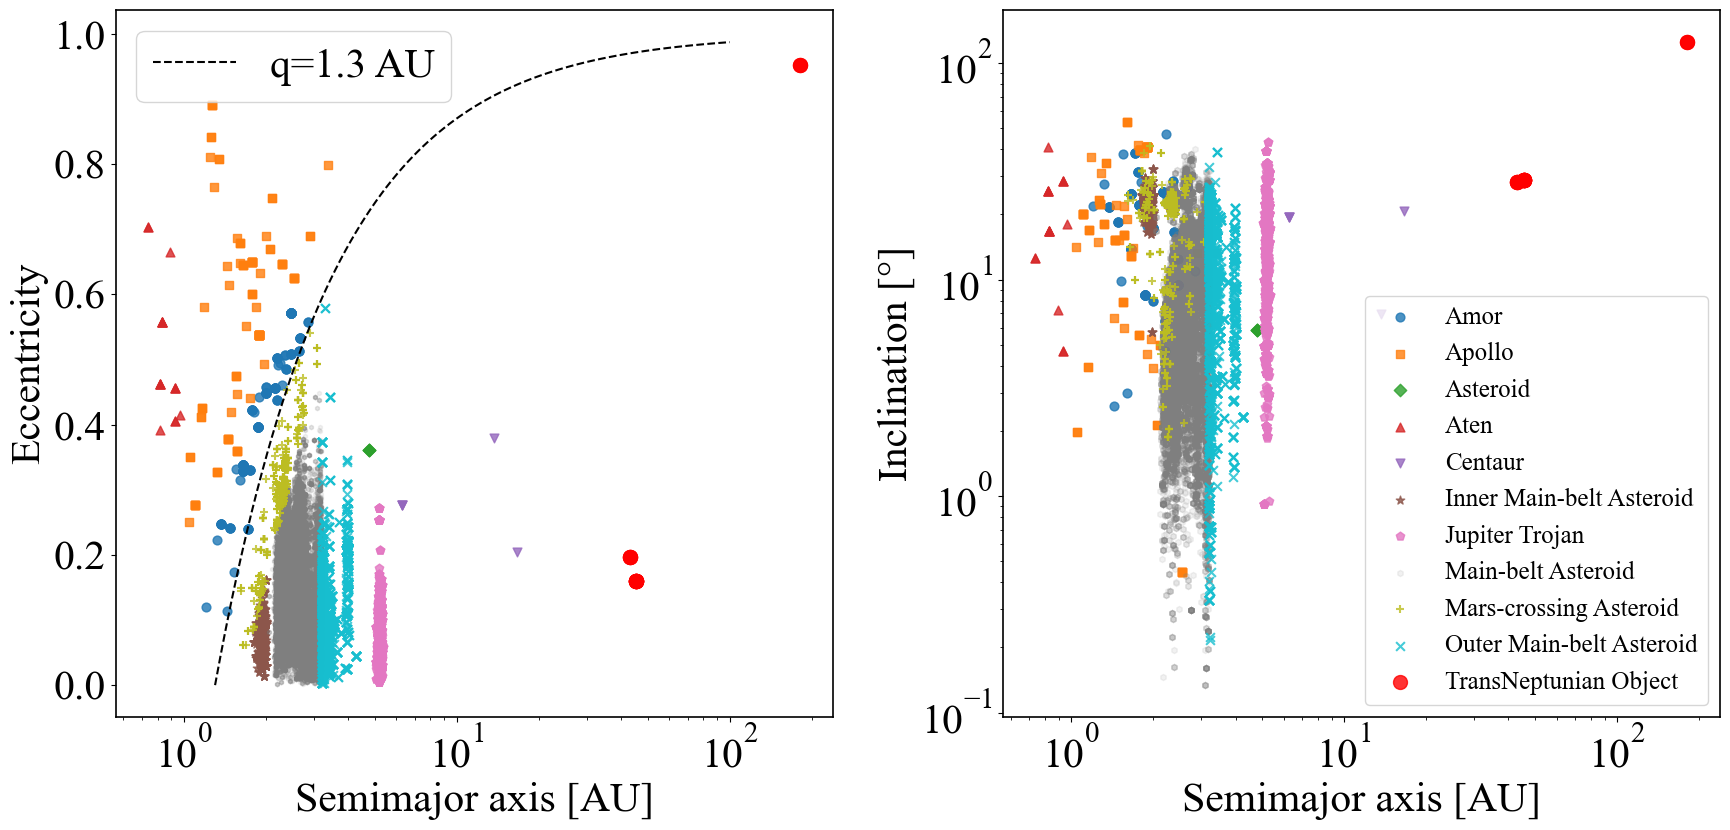

In [8]:
import matplotlib.pyplot as plt
from astropy.table import Table
import numpy as np

def str_to_float(arr, unit=None):
    """
    将 SBDB 保存的字符串数组转换为 float。
    如果字符串中有单位（如 'AU', 'deg'），去掉单位再转 float。
    无效数值（空字符串、'--'）自动转 np.nan
    """
    out = []
    for x in arr:
        if x is None:
            out.append(np.nan)
            continue
        s = str(x).strip()
        if s in ('', '--', 'nan', 'NaN'):
            out.append(np.nan)
            continue
        if unit and s.endswith(unit):
            s = s[:-len(unit)].strip()
        try:
            out.append(float(s))
        except ValueError:
            out.append(np.nan)
    return np.array(out, dtype=float)

# -----------------------------
# 1. 读取 FITS
# -----------------------------
t = Table.read("/Users/yunaoxiao/Desktop/sitian.fits")

# -----------------------------
# 2. 提取并转换数据
# -----------------------------
a = str_to_float(t['orbit_elements_a'], unit='AU')
e = str_to_float(t['orbit_elements_e'])        # 离心率本身无单位
i = str_to_float(t['orbit_elements_i'], unit='deg')
classes = np.array(t['object_orbit_class_name'], dtype=str)

# -----------------------------
# 3. 分类准备
# -----------------------------
unique_classes = np.unique(classes)
markers = ['o', 's', 'D', '^', 'v', '*', 'p', 'h', '+', 'x']
colors = plt.cm.tab10.colors  # 默认10色循环

class_marker_color = {}
for idx, cls in enumerate(unique_classes):
    class_marker_color[cls] = (markers[idx % len(markers)],
                               colors[idx % len(colors)])

# -----------------------------
# 4. 创建画布和子图
# -----------------------------
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 30

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
ax1, ax2 = axes

# -----------------------------
# 5. 绘制 a vs e（左图）
# -----------------------------
for cls in unique_classes:
    mask = classes == cls
    if cls == 'TransNeptunian Object':
        alpha_val = 0.8
        color_val = 'r'
        size_val = 100
    elif cls == 'Main-belt Asteroid':
        alpha_val = 0.1
        color_val = class_marker_color[cls][1]
        size_val = 10
    else:
        alpha_val = 0.8
        color_val = class_marker_color[cls][1]
        size_val = 40

    ax1.scatter(a[mask], e[mask],
                marker=class_marker_color[cls][0],
                color=color_val,
                s=size_val,
                alpha=alpha_val)

# q = 1.3 AU 虚线
a_line = np.logspace(np.log10(1.3), 2, 100)
e_line = 1 - 1.3 / a_line
ax1.plot(a_line, e_line, 'k--', label='q=1.3 AU')
ax1.legend()
ax1.set_xscale('log')
ax1.set_xlabel('Semimajor axis [AU]')
ax1.set_ylabel('Eccentricity')

# -----------------------------
# 6. 绘制 a vs i（右图）
# -----------------------------
for cls in unique_classes:
    mask = classes == cls
    if cls == 'TransNeptunian Object':
        alpha_val = 0.8
        color_val = 'r'
        size_val = 100
    elif cls == 'Main-belt Asteroid':
        alpha_val = 0.1
        color_val = class_marker_color[cls][1]
        size_val = 20
    else:
        alpha_val = 0.8
        color_val = class_marker_color[cls][1]
        size_val = 40

    ax2.scatter(a[mask], i[mask],
                marker=class_marker_color[cls][0],
                color=color_val,
                s=size_val,
                alpha=alpha_val,
                label=cls)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Semimajor axis [AU]')
ax2.set_ylabel('Inclination [°]')
ax2.legend(fontsize=18, loc='best')

plt.tight_layout()
plt.savefig('/Users/yunaoxiao/Desktop/asteroid_orbits.png', dpi=300)
plt.show()


/opt/anaconda3/envs/jupyter/lib/python3.9/site-packages/matplotlib/cbook.py:1762: UserWarning: Warning: converting a masked element to nan.
  return math.isfinite(val)
/var/folders/1g/dt2h42hd0hv32hvbf1grqvd40000gn/T/ipykernel_53099/2539417764.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


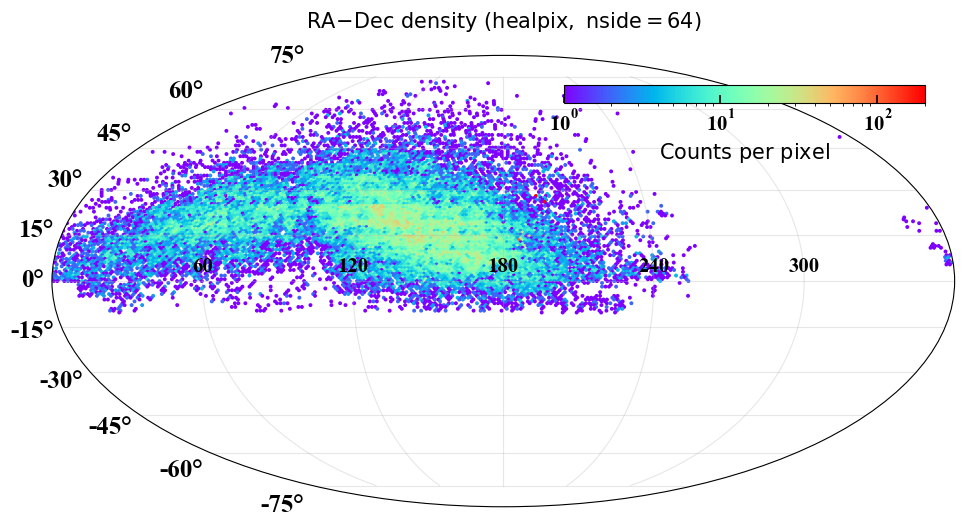

Saved: /Users/yunaoxiao/Desktop/sitian_ra_dec_healpix_nside64_counts_linear_clim0_200.png


In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import healpy as hp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LogNorm

# ===============================
# 1. User config
# ===============================
FITS_PATH = "/Users/yunaoxiao/Desktop/sitian.fits"
OUTDIR = "/Users/yunaoxiao/Desktop"
os.makedirs(OUTDIR, exist_ok=True)

COL_RA  = "ra"
COL_DEC = "dec"

# Healpix
NSIDE = 64
NEST = False
NPIX = hp.nside2npix(NSIDE)

# ===============================
# 0. Font  (完全按你原来的)
# ===============================
font = {'family': 'Times New Roman', 'size': 18, 'weight': 'bold'}
plt.rc('font', **font)

# ===============================
# 2. Helpers  (完全照你给的写法)
# ===============================
def safe_mask(*arrs):
    m = np.ones_like(arrs[0], dtype=bool)
    for a in arrs:
        m &= np.isfinite(a)
    return m

def radec_to_pix(ra_deg, dec_deg, nside=64, nest=False):
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    theta = 0.5*np.pi - dec
    phi = ra % (2*np.pi)
    return hp.ang2pix(nside, theta, phi, nest=nest)

def ra_to_mollweide_lon_rad(ra_deg, center_deg=180.0):
    lon_deg = (ra_deg - center_deg)  # shift
    lon_deg = (lon_deg + 180.0) % 360.0 - 180.0  # wrap to [-180,180)
    return np.deg2rad(lon_deg)

def set_mollweide_ra_ticks_0_360(ax, center_deg=180.0, step=60):
    # 与你贴的保持一致：不包含0、也不包含360（只标 60..300）
    ra_labels = np.arange(step, 301, step)
    lon_ticks = ra_to_mollweide_lon_rad(ra_labels, center_deg=center_deg)
    ax.set_xticks(lon_ticks)
    ax.set_xticklabels([f"{v:d}" for v in ra_labels], fontsize=15)

def apply_specdis_style(ax):
    ax.minorticks_on()
    ax.tick_params(which="major", direction="in", bottom=True, left=True,
                   labelsize=16, length=7, width=1.3)
    ax.tick_params(which="minor", direction="in", bottom=True, left=True,
                   length=4, width=1.0)

def add_inset_colorbar_specdis(fig, ax, mappable, label):
    cax = inset_axes(ax, width="40%", height="4%", loc="upper right", borderpad=1.2)
    cb = fig.colorbar(mappable, cax=cax, orientation="horizontal")
    cb.set_label(label, fontsize=15)
    cb.ax.tick_params(labelsize=15, direction="in", length=6, width=1.2)
    return cb

# ===============================
# 3. Read FITS + Healpix counts
# ===============================
t = Table.read(FITS_PATH)
ra  = np.asarray(t[COL_RA], dtype=float)
dec = np.asarray(t[COL_DEC], dtype=float)

m = safe_mask(ra, dec) & (dec > -90) & (dec < 90)
ra = ra[m]
dec = dec[m]

pix = radec_to_pix(ra, dec, nside=NSIDE, nest=NEST)
hp_counts = np.bincount(pix, minlength=NPIX).astype(np.float64)

# ===============================
# 6. Plot: RA-Dec healpix counts (linear, no-color where 0)
# ===============================
ipix = np.arange(NPIX)
theta, phi = hp.pix2ang(NSIDE, ipix, nest=NEST)
dec_c = np.rad2deg(0.5*np.pi - theta)
ra_c  = np.rad2deg(phi)  # [0,360)

lon = ra_to_mollweide_lon_rad(ra_c, center_deg=180.0)
lat = np.deg2rad(dec_c)

cmap = plt.get_cmap("rainbow").copy()
cmap.set_bad(alpha=0.0)

counts = hp_counts.astype(np.float64)

# 对数：0 必须 mask；显示值 clip 到 [1,200]
counts_plot = np.clip(counts, 1, 200)
val = np.ma.masked_where(counts == 0, counts_plot)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="mollweide")

im = ax.scatter(
    lon, lat,
    c=val,
    s=8,
    linewidths=0,
    cmap=cmap,
    norm=LogNorm(vmin=1, vmax=200)
)

ax.grid(True, alpha=0.3)
set_mollweide_ra_ticks_0_360(ax, center_deg=180.0, step=60)

ax.set_title(r"$\mathrm{RA\!-\!Dec\ density\ (healpix,\ nside=64)}$", fontsize=15, pad=20)

# 你原程序这里没调用 apply_specdis_style；如果你想完全一致就不调用
# apply_specdis_style(ax)

add_inset_colorbar_specdis(fig, ax, im, r"$\mathrm{Counts\ per\ pixel}$")

plt.tight_layout()
outpng = os.path.join(OUTDIR, "sitian_ra_dec_healpix_nside64_counts_linear_clim0_200.png")
plt.savefig(outpng, dpi=250)
plt.show()

print("Saved:", outpng)


In [11]:
import numpy as np
from astropy.table import Table
import healpy as hp

FITS_PATH = "/Users/yunaoxiao/Desktop/sitian.fits"

# -----------------------------
# 0) helpers
# -----------------------------
def _as_str_array(col):
    x = np.array(col)
    out = np.empty(len(x), dtype=object)
    for i, v in enumerate(x):
        if v is None:
            out[i] = ""
        elif isinstance(v, (bytes, bytearray)):
            out[i] = v.decode(errors="ignore").strip()
        else:
            out[i] = str(v).strip()
    return out.astype(str)

def _is_true_like(s):
    s = s.strip().lower()
    return s in ("y","yes","true","t","1")

def pick_object_id(tab):
    # 优先用稳定ID：spkid > orbit_id > number > name
    for k in ["object_spkid", "object_orbit_id", "number", "name", "object_shortname", "object_fullname"]:
        if k in tab.colnames:
            arr = tab[k]
            # 处理 number 是 float 的情况：去掉 .0
            if k == "number":
                a = np.array(arr)
                ok = np.isfinite(a)
                out = np.array(["" for _ in range(len(a))], dtype=object)
                out[ok] = [str(int(v)) if float(v).is_integer() else str(v) for v in a[ok]]
                return out.astype(str), k
            return _as_str_array(arr), k
    raise ValueError("No suitable object id column found.")

def radec_to_pix(ra_deg, dec_deg, nside=64, nest=False):
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    theta = 0.5*np.pi - dec
    phi = ra % (2*np.pi)
    return hp.ang2pix(nside, theta, phi, nest=nest)

# -----------------------------
# 1) read
# -----------------------------
t = Table.read(FITS_PATH)
N_row = len(t)

obj_id, obj_id_col = pick_object_id(t)
uobj = np.unique(obj_id[obj_id != ""])
N_obj = len(uobj)

# 轨道族（用于 orbit 图的分类统计）
cls = _as_str_array(t["object_orbit_class_name"]) if "object_orbit_class_name" in t.colnames else np.array([""]*N_row)
ucls, cls_counts = np.unique(cls[cls != ""], return_counts=True)
cls_count_dict = dict(zip(ucls, cls_counts))

# -----------------------------
# 2) NEO 统计（两种判据：object_neo 标记 + 轨道族(Amor/Apollo/Aten/Atira)）
# -----------------------------
neo_flag = None
if "object_neo" in t.colnames:
    neo_flag = np.array([_is_true_like(s) for s in _as_str_array(t["object_neo"])], dtype=bool)
else:
    neo_flag = np.zeros(N_row, dtype=bool)

neo_by_class = np.isin(cls, ["Amor", "Apollo", "Aten", "Atira"])

neo = neo_flag | neo_by_class

N_neo_row = int(neo.sum())
neo_obj = np.unique(obj_id[neo & (obj_id != "")])
N_neo_obj = len(neo_obj)

frac_neo_row = N_neo_row / N_row if N_row > 0 else np.nan
frac_neo_obj = N_neo_obj / N_obj if N_obj > 0 else np.nan

# NEO 内部分类
neo_cls_names = ["Amor","Apollo","Aten","Atira"]
neo_break = {}
for c in neo_cls_names:
    m = (cls == c)
    neo_break[c] = {
        "rows": int(m.sum()),
        "objs": len(np.unique(obj_id[m & (obj_id != "")]))
    }

# -----------------------------
# 3) 天区/footprint 统计（healpix nside=64）
# -----------------------------
ra = np.array(t["ra"], dtype=float)
dec = np.array(t["dec"], dtype=float)
m = np.isfinite(ra) & np.isfinite(dec) & (dec > -90) & (dec < 90)

NSIDE = 64
NPIX = hp.nside2npix(NSIDE)
pix = radec_to_pix(ra[m], dec[m], nside=NSIDE, nest=False)
hp_counts = np.bincount(pix, minlength=NPIX).astype(float)

nonzero = hp_counts > 0
N_pix_nz = int(nonzero.sum())

pix_area_sr = hp.nside2pixarea(NSIDE)             # steradian
pix_area_deg2 = pix_area_sr * (180/np.pi)**2      # deg^2
area_deg2 = N_pix_nz * pix_area_deg2

max_cnt = float(np.max(hp_counts)) if N_pix_nz > 0 else 0.0
p50_cnt = float(np.median(hp_counts[nonzero])) if N_pix_nz > 0 else 0.0
mean_cnt = float(np.mean(hp_counts[nonzero])) if N_pix_nz > 0 else 0.0

# 你图里 colorbar 0–200（或 log 1–200）会饱和：统计一下超出比例
gt200 = int(np.sum(hp_counts > 200))
frac_gt200 = gt200 / N_pix_nz if N_pix_nz > 0 else np.nan

# -----------------------------
# 4) 打印统计
# -----------------------------
print("===== Basic =====")
print(f"Total detections (rows): {N_row:,}")
print(f"Unique objects ({obj_id_col}): {N_obj:,}")

print("\n===== NEO =====")
print(f"NEO detections (rows): {N_neo_row:,}  ({frac_neo_row:.3%} of detections)")
print(f"NEO unique objects:     {N_neo_obj:,}  ({frac_neo_obj:.3%} of objects)")
print("NEO breakdown (by class):")
for c in neo_cls_names:
    print(f"  {c:6s}: rows={neo_break[c]['rows']:,}, objs={neo_break[c]['objs']:,}")

print("\n===== Orbit-class counts (rows) =====")
for k in sorted(cls_count_dict.keys()):
    print(f"  {k:25s}: {cls_count_dict[k]:,}")

print("\n===== Sky map / Healpix =====")
print(f"NSIDE={NSIDE}, NPIX={NPIX}, pixel area={pix_area_deg2:.4f} deg^2")
print(f"Non-zero pixels: {N_pix_nz:,}")
print(f"Approx. covered area (non-zero pixels): {area_deg2:,.1f} deg^2")
print(f"Counts per pixel (non-zero): median={p50_cnt:.1f}, mean={mean_cnt:.1f}, max={max_cnt:.0f}")
print(f"Pixels with counts>200: {gt200:,}  ({frac_gt200:.3%} of non-zero pixels)")

# -----------------------------
# 5) 自动生成图注（你可直接复制粘贴）
# -----------------------------
caption_orbit = (
    "图 X｜司天原型机观测样本的小行星轨道参数分布（左：离心率 e–半长轴 a；右：倾角 i–半长轴 a）。"
    "点的形状/颜色区分不同轨道族（如主带、小行星近地族 Amor/Apollo/Aten 等）。"
    "左图虚线为近日点距离 q=1.3 AU 的边界（q=a(1−e)），常用作近地小行星（NEO）判据之一。"
    f"本样本共包含 {N_row:,} 条测量（{N_obj:,} 个独立天体，ID={obj_id_col}）。"
    f"其中 NEO 共 {N_neo_obj:,} 个（占 {frac_neo_obj:.2%}），对应 {N_neo_row:,} 条测量（占 {frac_neo_row:.2%}）。"
    f"NEO 内部分别为 Amor {neo_break['Amor']['objs']:,} 个、Apollo {neo_break['Apollo']['objs']:,} 个、"
    f"Aten {neo_break['Aten']['objs']:,} 个、Atira {neo_break['Atira']['objs']:,} 个。"
)

caption_sky = (
    f"图 Y｜司天原型机小行星样本在赤道坐标系下的天区密度分布（Mollweide 投影），采用 HEALPix NSIDE={NSIDE}（单像素面积 {pix_area_deg2:.4f} deg²）。"
    "颜色表示每个像素内的观测点数（counts per pixel），零计数像素被屏蔽为透明。"
    f"非零像素数为 {N_pix_nz:,}，对应的近似覆盖面积为 {area_deg2:,.1f} deg²。"
    f"非零像素的 counts 中位数/均值/最大值分别为 {p50_cnt:.1f}/{mean_cnt:.1f}/{max_cnt:.0f}。"
    f"在设定的色标上限 200 counts/pixel 下，有 {gt200:,} 个像素超过上限（占非零像素的 {frac_gt200:.2%}），这些区域在图中显示为饱和颜色。"
)

print("\n===== Suggested captions =====")
print("\n[Orbit figure caption]\n", caption_orbit)
print("\n[Sky density figure caption]\n", caption_sky)


===== Basic =====
Total detections (rows): 56,230
Unique objects (object_spkid): 16,053

===== NEO =====
NEO detections (rows): 259  (0.461% of detections)
NEO unique objects:     77  (0.480% of objects)
NEO breakdown (by class):
  Amor  : rows=139, objs=31
  Apollo: rows=101, objs=38
  Aten  : rows=19, objs=8
  Atira : rows=0, objs=0

===== Orbit-class counts (rows) =====
  Amor                     : 139
  Apollo                   : 101
  Asteroid                 : 3
  Aten                     : 19
  Centaur                  : 5
  Inner Main-belt Asteroid : 897
  Jupiter Trojan           : 1,362
  Main-belt Asteroid       : 51,058
  Mars-crossing Asteroid   : 656
  Outer Main-belt Asteroid : 1,970
  TransNeptunian Object    : 20

===== Sky map / Healpix =====
NSIDE=64, NPIX=49152, pixel area=0.8393 deg^2
Non-zero pixels: 9,960
Approx. covered area (non-zero pixels): 8,359.4 deg^2
Counts per pixel (non-zero): median=3.0, mean=5.6, max=311
Pixels with counts>200: 2  (0.020% of non-zero 